1. Importing necessary modules and reading the data

In [146]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                             precision_score, recall_score, f1_score, accuracy_score,roc_auc_score,pairwise_distances,log_loss)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import joblib as joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


In [64]:
data = pd.read_csv('bank-full.csv', delimiter=";")

data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


2. Exploratory Data Analysis (EDA) Let’s analyze distributions, correlations, and missing values.


In [65]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [67]:
data["y"].value_counts()

,count
y,
no,39922
yes,5289


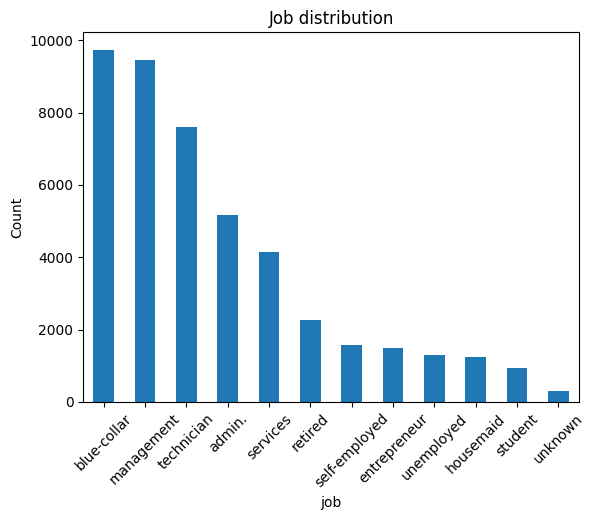

In [68]:
data["job"].value_counts().plot(kind="bar")
plt.title("Job distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

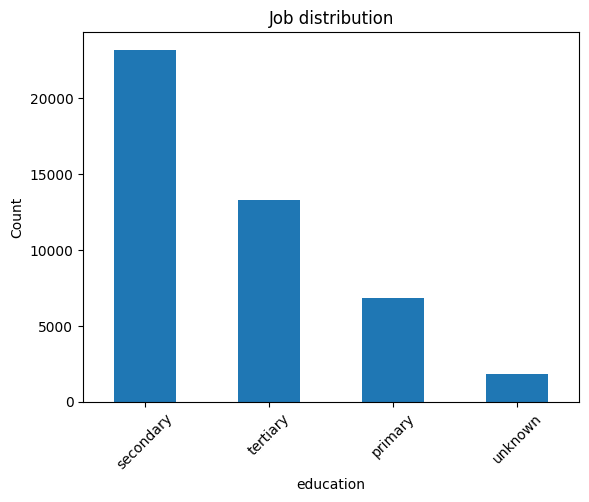

In [69]:
data["education"].value_counts().plot(kind="bar")
plt.title("Job distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

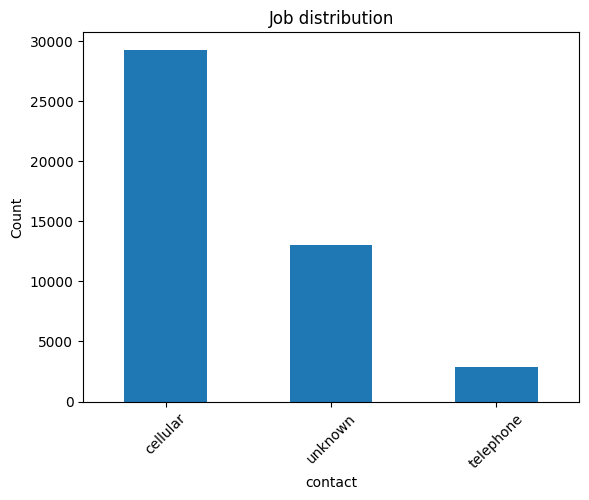

In [70]:
data["contact"].value_counts().plot(kind="bar")
plt.title("Job distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

3. Feature Engineering

In [71]:
data['y'] = data['y'].map({'yes':1, 'no':0})

In [72]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


In [73]:
data_clean = data.replace("unknown", np.nan)
data_clean.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


In [74]:
X = data_clean.drop('y', axis=1)
y = data_clean['y']

In [75]:
numCol = X.select_dtypes(include=["int64", "float64"]).columns

In [76]:
catCol = X.select_dtypes(include=["object"]).columns


In [77]:
unknown_by_col = (data == "unknown").sum().sort_values(ascending=False)
unknown_by_col

,0
poutcome,36959
contact,13020
education,1857
job,288
age,0
default,0
balance,0
housing,0
marital,0
loan,0


In [78]:
data_clean.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,0
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,0
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,0
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,0


In [79]:
data_clean['education'].unique()


array(['tertiary', 'secondary', nan, 'primary'], dtype=object)

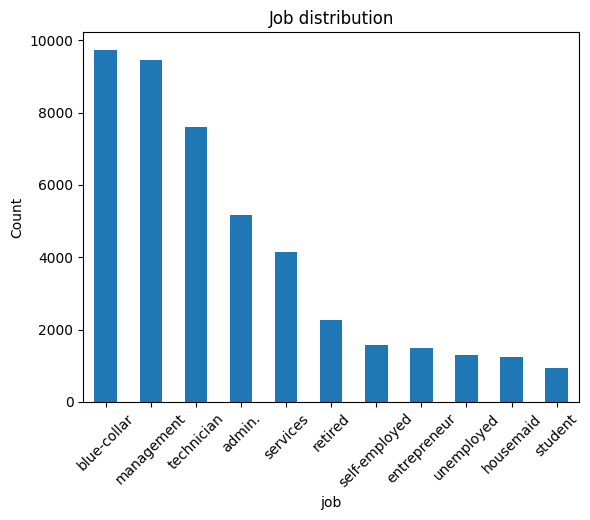

In [80]:
data_clean["job"].value_counts().plot(kind="bar")
plt.title("Job distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

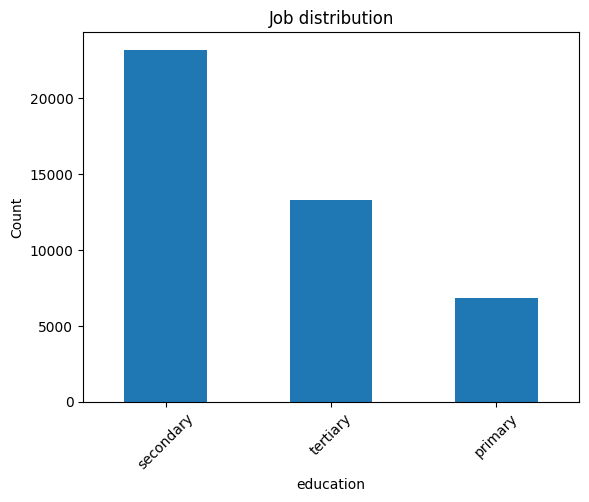

In [81]:
data_clean["education"].value_counts().plot(kind="bar")
plt.title("Job distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

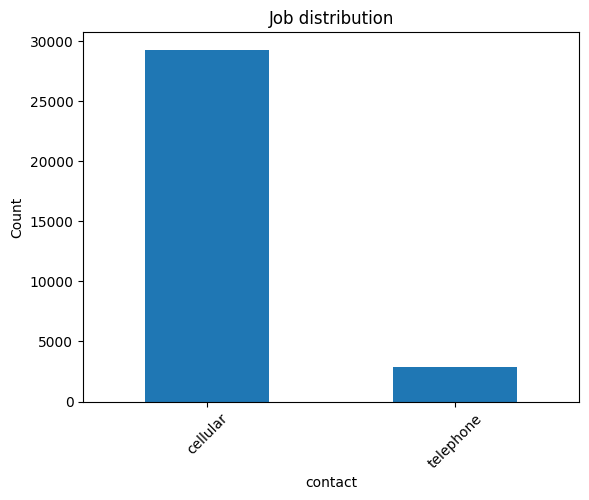

In [82]:
data_clean["contact"].value_counts().plot(kind="bar")
plt.title("Job distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Missing values represented by "unknown" were converted to NaN and handled within the preprocessing pipeline. Numerical missing values were replaced using the training-set mean, while categorical missing values were replaced using the most frequent category. This preprocessing was performed within the pipeline to prevent data leakage between the training and testing datasets.

In [83]:
numT = Pipeline(steps=[('imputer', SimpleImputer(strategy = 'mean')), ('scaler', StandardScaler())])
catT = Pipeline(steps=[('imputer', SimpleImputer(strategy = 'most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [84]:
ct = ColumnTransformer(transformers=[('num', numT, numCol), ('cat', catT, catCol)])

MODEL 1 : LOGISTIC REGRESSION without class weight=balanced

In [85]:
model1 = Pipeline(steps=[('preprocessor', ct),('classifier', LogisticRegression(max_iter=1000))])

lets create the training and testing sets

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

lets fit the model to the training set

In [87]:
model1.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

the model will now predict the values of the test set

In [105]:
lr_pred = model1.predict(X_test)

In [106]:
print(classification_report(y_test, lr_pred))

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1:", f1_score(y_test, lr_pred))

confusion_matrix(y_test, lr_pred)

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7985
           1       0.63      0.33      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043

Accuracy: 0.899037929890523
Precision: 0.631578947368421
Recall: 0.32892249527410206
F1: 0.43256681168427596


array([[7782,  203],
       [ 710,  348]])

## **MODEL 2 : Logistic regression with class weight = balanced**

In [90]:
model2 = Pipeline(steps=[('preprocessor', ct),('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))])

In [91]:
model2.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [107]:
lrb_pred = model2.predict(X_test)

In [108]:
print(classification_report(y_test, lrb_pred))

print("Accuracy:", accuracy_score(y_test, lrb_pred))
print("Precision:", precision_score(y_test, lrb_pred))
print("Recall:", recall_score(y_test, lrb_pred))
print("F1:", f1_score(y_test, lrb_pred))

confusion_matrix(y_test, lrb_pred)

              precision    recall  f1-score   support

           0       0.97      0.85      0.90      7985
           1       0.41      0.79      0.54      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.82      0.72      9043
weighted avg       0.90      0.84      0.86      9043

Accuracy: 0.8404290611522724
Precision: 0.40686985970004835
Recall: 0.7948960302457467
F1: 0.53824


array([[6759, 1226],
       [ 217,  841]])

The recall is significantly higher which implies that the model is able to identify if the outcome is 1. The previous model fitted on an imbalanced dataset with more than 80% of the outcomes being 0 so it could blindly label all outcomes of the test as 0 and still have 80+ accuracy

Let us use SMOTE to synthesize data points to balance the data set and see if the models perform better

In [98]:


smote_lr = Pipeline([
    ('preprocessor', ct),
    ('smote', SMOTE(sampling_strategy="minority",random_state=1)),
    ('classifier', LogisticRegression(max_iter=1000))
])


In [99]:
smote_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=1, sampling_strategy='minority')),
                ('classifier', LogisticRegression(max_iter=1000))])

In [115]:
slr_pred = smote_lr.predict(X_test)

In [116]:
print(classification_report(y_test, slr_pred))

print("Accuracy:", accuracy_score(y_test, slr_pred))
print("Precision:", precision_score(y_test, slr_pred))
print("Recall:", recall_score(y_test, slr_pred))
print("F1:", f1_score(y_test, slr_pred))

confusion_matrix(y_test, slr_pred)

              precision    recall  f1-score   support

           0       0.97      0.85      0.90      7985
           1       0.41      0.79      0.54      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.82      0.72      9043
weighted avg       0.90      0.84      0.86      9043

Accuracy: 0.8406502266946809
Precision: 0.40635696821515893
Recall: 0.7854442344045368
F1: 0.5356106993232356


array([[6771, 1214],
       [ 227,  831]])

did not make much of a difference in logistic regression, actually decreased

## **Model 4 : Random Forest Classifier**





In [144]:

rf_model = Pipeline([
    ('preprocessor', ct),
    ('classifier', RandomForestClassifier(
        n_estimators=500,
        criterion='gini',
        max_depth=7,
        max_features='sqrt',
        random_state=1
    ))
])

In [145]:
rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(max_depth=7, n_estimators=500,
                                        random_state=1))])

In [147]:
rf_pred = rf_model.predict(X_test)

In [148]:
print(classification_report(y_test, rf_pred))

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

confusion_matrix(y_test, rf_pred)

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.79      0.16      0.26      1058

    accuracy                           0.90      9043
   macro avg       0.85      0.57      0.60      9043
weighted avg       0.89      0.90      0.86      9043

Accuracy: 0.8963839433816212
Precision: 0.7922705314009661
Recall: 0.15500945179584122
F1: 0.2592885375494071


array([[7942,   43],
       [ 894,  164]])

In [149]:
rf_model = Pipeline([
    ('preprocessor', ct),
    ('smote', SMOTE(sampling_strategy="minority",random_state=1)),
    ('classifier', RandomForestClassifier(
        n_estimators=500,
        criterion='gini',
        max_depth=7,
        max_features='sqrt',
        random_state=1))

])

In [150]:
rf_model.fit(X_train, y_train)
srf_pred = rf_model.predict(X_test)

In [151]:
print(classification_report(y_test, srf_pred))

print("Accuracy:", accuracy_score(y_test, srf_pred))
print("Precision:", precision_score(y_test, srf_pred))
print("Recall:", recall_score(y_test, srf_pred))
print("F1:", f1_score(y_test, srf_pred))

confusion_matrix(y_test, srf_pred)

              precision    recall  f1-score   support

           0       0.97      0.85      0.90      7985
           1       0.41      0.78      0.54      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.82      0.72      9043
weighted avg       0.90      0.84      0.86      9043

Accuracy: 0.8405396439234767
Precision: 0.4060665362035225
Recall: 0.7844990548204159
F1: 0.5351386202450032


array([[6771, 1214],
       [ 228,  830]])

using smote significantly increased the recall of the random forest classifier model

lets try using randomsearchcv to find the best model for random forest classifer

In [120]:
param_grid = {
    'classifier__n_estimators': [200, 500, 800],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__max_depth' : [4,5,6,7,8],
    'classifier__criterion' :['gini', 'entropy']
}

cv_model = Pipeline([
    ('preprocessor', ct),
    ('smote', SMOTE(sampling_strategy="minority",random_state=1)),
    ('classifier', RandomForestClassifier())

])



In [121]:
random_search = RandomizedSearchCV(
    cv_model,
    param_grid,
    n_iter=20,
    cv=3,
    scoring="recall",
    n_jobs=-1,
    random_state=0
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot...
      dtype='object'))])),
                                             ('smote',
                                              SMOTE(random_state=1,
                                                    sampling_strategy='minority')),
                                             ('classifier',
                                              RandomForestClassifier())]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__criterion': ['gini',
                                                                  'entropy'],
                                        'classifier__max_depth': [4, 5, 6, 7,
                                                                  8],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2'],
                                        'classifier__n_estimators': [200, 500,
                                                                     800]},
                   random_state=0, scoring='recall')

In [152]:
print(random_search.best_params_)

{'classifier__n_estimators': 800, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 8, 'classifier__criterion': 'gini'}


In [153]:
cv_pred = random_search.predict(X_test)


In [154]:
print(classification_report(y_test, cv_pred))

print("Accuracy:", accuracy_score(y_test, cv_pred))
print("Precision:", precision_score(y_test, cv_pred))
print("Recall:", recall_score(y_test, cv_pred))
print("F1:", f1_score(y_test, cv_pred))

confusion_matrix(y_test, cv_pred)

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.41      0.78      0.54      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.82      0.72      9043
weighted avg       0.90      0.84      0.86      9043

Accuracy: 0.8441888753732169
Precision: 0.4122938530734633
Recall: 0.779773156899811
F1: 0.5393919581562602


array([[6809, 1176],
       [ 233,  825]])

In [155]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Balanced Logistic Regression',
        'Random Forest',
        'Logistic + Balanced + SMOTE',
        'Random Forest + SMOTE',
        'Tuned Random Forest + SMOTE'
    ],
    'Accuracy': [
        accuracy_score(y_test, model1.predict(X_test)),
        accuracy_score(y_test, model2.predict(X_test)),
        accuracy_score(y_test, rf_model.predict(X_test)),
        accuracy_score(y_test, smote_lr.predict(X_test)),
        accuracy_score(y_test, srf_pred),
        accuracy_score(y_test, random_search.predict(X_test))
    ],
    'Precision': [
        precision_score(y_test, model1.predict(X_test)),
        precision_score(y_test, model2.predict(X_test)),
        precision_score(y_test, rf_model.predict(X_test)),
        precision_score(y_test, smote_lr.predict(X_test)),
        precision_score(y_test, srf_pred),
        precision_score(y_test, random_search.predict(X_test))],
    'Recall': [
        recall_score(y_test, model1.predict(X_test)),
        recall_score(y_test, model2.predict(X_test)),
        recall_score(y_test, rf_model.predict(X_test)),
        recall_score(y_test, smote_lr.predict(X_test)),
        recall_score(y_test, srf_pred),
        recall_score(y_test, random_search.predict(X_test))
    ],
    'F1':[
        f1_score(y_test, model1.predict(X_test)),
        f1_score(y_test, model2.predict(X_test)),
        f1_score(y_test, rf_model.predict(X_test)),
        f1_score(y_test, smote_lr.predict(X_test)),
        f1_score(y_test, srf_pred),
        f1_score(y_test, random_search.predict(X_test))
    ],
    'ROC-AUC':[
        roc_auc_score(y_test, model1.predict(X_test)),
        roc_auc_score(y_test, model2.predict(X_test)),
        roc_auc_score(y_test, rf_model.predict(X_test)),
        roc_auc_score(y_test, smote_lr.predict(X_test)),
        roc_auc_score(y_test, srf_pred),
        roc_auc_score(y_test, random_search.predict(X_test))
    ]
})

In [156]:
print(results)

                          Model  Accuracy  Precision    Recall        F1  \
0           Logistic Regression  0.899038   0.631579  0.328922  0.432567   
1  Balanced Logistic Regression  0.840429   0.406870  0.794896  0.538240   
2                 Random Forest  0.840540   0.406067  0.784499  0.535139   
3   Logistic + Balanced + SMOTE  0.840650   0.406357  0.785444  0.535611   
4         Random Forest + SMOTE  0.840540   0.406067  0.784499  0.535139   
5   Tuned Random Forest + SMOTE  0.844189   0.412294  0.779773  0.539392   

    ROC-AUC  
0  0.651750  
1  0.820679  
2  0.816232  
3  0.816705  
4  0.816232  
5  0.816249  


The results demonstrate that class imbalance significantly affected the performance of the baseline models. Although the baseline Logistic Regression model achieved the highest accuracy of 89.90%, it achieved a recall of only 32.89% and an F1-score of 0.43 for the minority class. This indicates that the model failed to identify a substantial proportion of customers who subscribed to the term deposit.

Applying class weighting to Logistic Regression improved minority-class performance, increasing recall to 79.49%, F1-score to 0.54, and ROC-AUC to 0.82. Random Forest models achieved comparable performance, but neither SMOTE nor hyperparameter optimisation resulted in substantial improvements. The tuned Random Forest with SMOTE achieved an F1-score of 0.54, only marginally higher than the balanced Logistic Regression model, while its ROC-AUC was slightly lower.

Therefore, Balanced Logistic Regression was selected as the final model for deployment. It provided a strong balance between minority-class recall and overall predictive performance while also offering lower computational complexity and greater interpretability than the Random Forest models

In [133]:
joblib.dump(model2,"bank_logistic_model.pkl")

['bank_logistic_model.pkl']